✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\38_poisson_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\38_poisson_3d.png


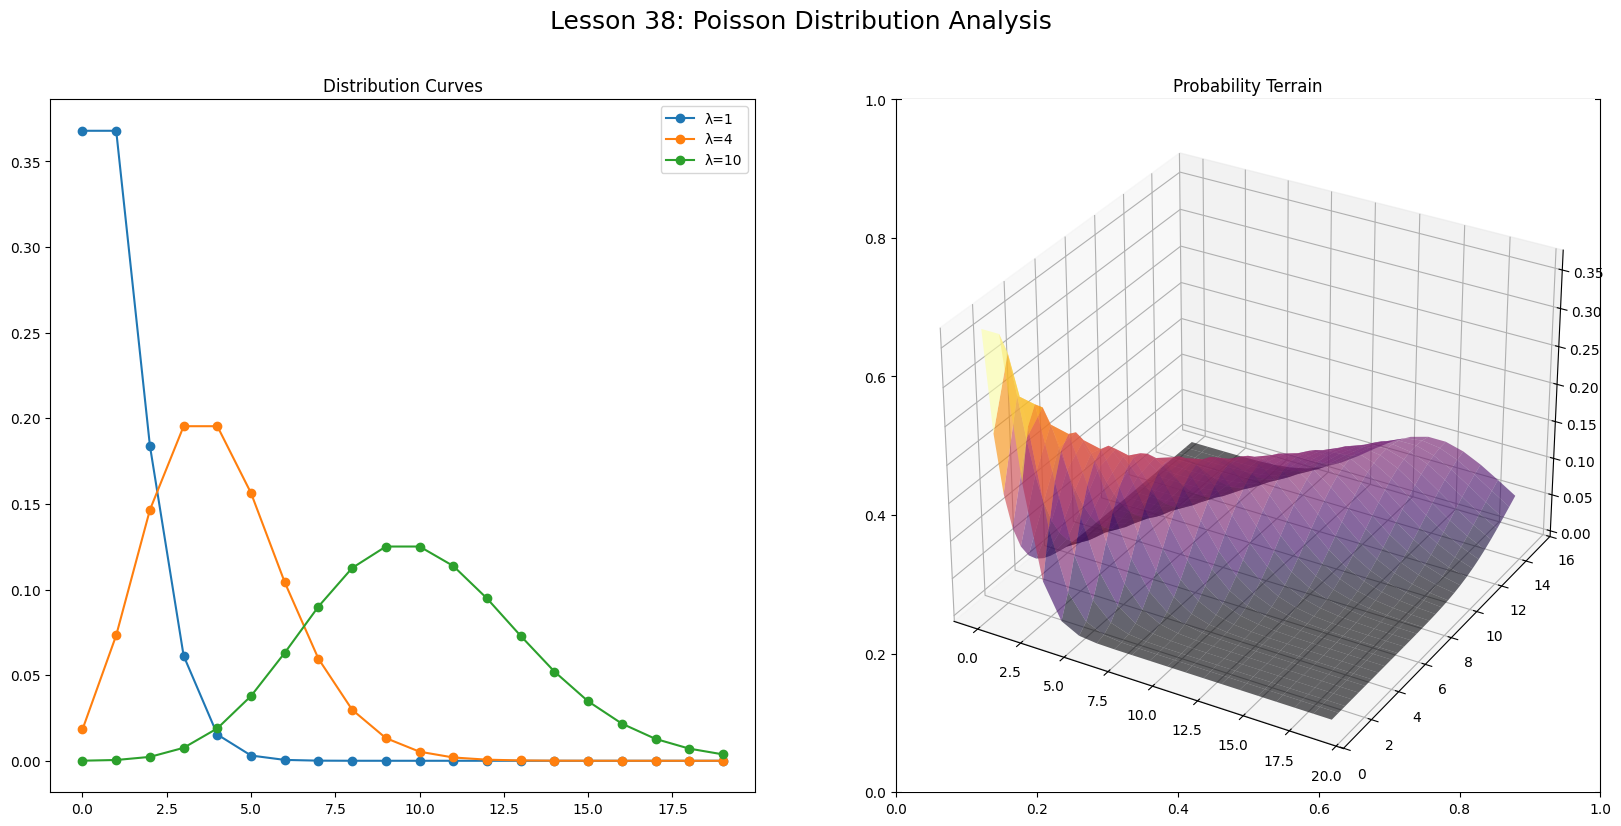

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
import os

def run_poisson_master():
    # --- YOL AYARI ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Hazırlık: Olay sayıları (k) ve Ortalama oranlar (lambda)
    k_range = np.arange(0, 20)
    lambdas = [1, 4, 10]

    # --- 📸 ASSET 1: SADECE 2D GRAFİK (38_poisson_2d.png) ---
    fig2d = plt.figure(figsize=(10, 7))
    ax2d = fig2d.add_subplot(111)
    
    colors = ['#FF5733', '#33FF57', '#3357FF']
    for i, lam in enumerate(lambdas):
        pmf = stats.poisson.pmf(k_range, lam)
        ax2d.step(k_range, pmf, where='mid', label=f'λ = {lam}', color=colors[i], marker='o', alpha=0.7)
    
    ax2d.set_title("2D Poisson Distribution: Probability Mass Function (PMF)", fontsize=14)
    ax2d.set_xlabel("Number of Events (k)")
    ax2d.set_ylabel("Probability")
    ax2d.legend()
    ax2d.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.savefig(os.path.join(asset_path, '38_poisson_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\38_poisson_2d.png")
    plt.close(fig2d)

    # --- 📸 ASSET 2: SADECE 3D GRAFİK (38_poisson_3d.png) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    # 3D Yüzey: Lambda değişimine karşı k olasılıkları
    lam_range = np.linspace(1, 15, 30)
    K, L = np.meshgrid(k_range, lam_range)
    Z = stats.poisson.pmf(K, L)

    surf = ax3d.plot_surface(K, L, Z, cmap='inferno', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D Poisson Probability Surface", fontsize=14)
    ax3d.set_xlabel('Events (k)')
    ax3d.set_ylabel('Mean Rate (λ)')
    ax3d.set_zlabel('Probability')
    
    plt.savefig(os.path.join(asset_path, '38_poisson_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\38_poisson_3d.png")
    plt.close(fig3d)

    # --- 🖥️ DASHBOARD (Preview) ---
    fig_dash, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(20, 9))
    
    # Left Preview
    for lam in lambdas:
        ax_l.plot(k_range, stats.poisson.pmf(k_range, lam), '-o', label=f'λ={lam}')
    ax_l.set_title("Distribution Curves")
    ax_l.legend()

    # Right Preview
    ax_r = fig_dash.add_subplot(122, projection='3d')
    ax_r.plot_surface(K, L, Z, cmap='inferno', alpha=0.6)
    ax_r.set_title("Probability Terrain")
    
    plt.suptitle("Lesson 38: Poisson Distribution Analysis", fontsize=18)
    plt.show()

if __name__ == "__main__":
    run_poisson_master()